# Evaluation and Activity Briefing

## Shared reporting for the intervention activity

This notebook is the handoff from the fixed baseline to the group investigation. It introduces the shared evaluation report, runs the baseline through that report, and explains what each group should record.

By the end, you should be able to:

1. use the shared report call for a trained run;
2. explain why intervention choices use validation evidence first;
3. read the baseline report without treating test results as a tuning signal;
4. record an experiment setup, result, and conclusion in the shared log;
5. identify the responsibility of each group notebook.

The goal is not to diagnose every failure here. The goal is to give everyone the same evidence protocol before the breakout starts.


In [2]:
import sys
print(sys.executable)

/home/sam/work/nextgen2026-mlai-workshops/.venv/bin/python


In [3]:
# Environment setup. The notebook is designed to run locally and in Colab.
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

REPO_URL = "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git"
REPO_BRANCH = "workshop3"
PACKAGE_NAME = "nextgen2026_mlai_workshops"

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                REPO_BRANCH,
                REPO_URL,
                str(repo_dir),
            ],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(repo_dir), "fetch", "--depth", "1", "origin", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "checkout", REPO_BRANCH], check=True)
        subprocess.run(["git", "-C", str(repo_dir), "pull", "--ff-only", "origin", REPO_BRANCH], check=True)

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    missing_packages = [
        package_name
        for package_name, module_name in (("pandas", "pandas"), ("torch", "torch"))
        if importlib.util.find_spec(module_name) is None
    ]
    if missing_packages:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing_packages], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    repo_dir = None
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / PACKAGE_NAME).exists():
            repo_dir = possible_root
            sys.path.insert(0, str(possible_src))
            break

for module_name in list(sys.modules):
    if module_name == PACKAGE_NAME or module_name.startswith(f"{PACKAGE_NAME}."):
        del sys.modules[module_name]

print(f"Workshop 3 environment ready. Repository: {repo_dir or 'installed environment'}")


Workshop 3 environment ready. Repository: /home/sam/work/nextgen2026-mlai-workshops


<br>

## 1. Where We Are

The fixed baseline from `02_our_approach` trained successfully, but it did not meet the combined project criterion on validation. That is why we now investigate rather than declare the project finished.

| Item | Current state |
|---|---|
| Baseline inputs | `irradiance`, `ambient_temperature`, `tilt_angle` |
| Baseline model | Width-16, depth-2 ReLU MLP |
| Training method | Plain SGD, no momentum, MSE loss |
| Selection evidence | Validation split |
| Baseline status | Fixed baseline did not meet the project criterion |
| Next question | What kind of intervention is justified by the evidence? |

Each group will test one class of explanation: data design, hypothesis space, or optimizer/objective. Keep those boundaries clear so the evidence stays interpretable.


In [4]:
# Load the baseline run used to demonstrate the shared evaluation report.
from nextgen2026_mlai_workshops import solar_pv as pv
import matplotlib.pyplot as plt

bundle = pv.make_workshop3_bundle("baseline", seed=7)
input_columns = ["irradiance", "ambient_temperature", "tilt_angle"]
baseline_config = pv.baseline_config()
baseline_run = pv.train_with_config(bundle, baseline_config, name="Baseline MLP")
show_advanced = False

pv.print_table(
    ["Baseline component", "Value"],
    [
        ["inputs", ", ".join(input_columns)],
        ["model", "width 16, depth 2, ReLU MLP"],
        ["loss and optimizer", "MSE with plain SGD"],
        ["validation criterion", "overall RMSE and key operating-range RMSE"],
    ],
)


| Baseline component   | Value                                       |
| :------------------- | :------------------------------------------ |
| inputs               | irradiance, ambient_temperature, tilt_angle |
| model                | width 16, depth 2, ReLU MLP                 |
| loss and optimizer   | MSE with plain SGD                          |
| validation criterion | overall RMSE and key operating-range RMSE   |


<br>

## 2. Shared Evaluation Report

All groups will evaluate trained runs with the same compact report. During intervention selection, use this validation-first call:

```python
report = pv.evaluate_model_report(
    run,
    bundle,
    include_test=False,
    show_advanced=False,
)
```

| Report field | What to inspect |
|---|---|
| Overall RMSE/MAE | Aggregate fit on train and validation |
| Criterion pass/fail | Whether validation evidence meets the project target |
| Key operating-range RMSE | Performance in the success slice |
| Slice table | Input regimes where errors are larger or biased |

Keep `show_advanced=False` for the default activity path. The report is a common evidence format, not a complete explanation of why a model fails.


<br>

## 3. Validation-First Rule

Choose interventions using validation evidence. Use test evidence only after the choice is fixed.

This keeps the test split as final evidence about a fixed claim. If test performance changes the model, the data collection choice, the input set, the optimizer settings, or the reporting rule, then test has been turned into another validation set.


<br>

## 4. Baseline Validation Report

Everyone starts from the same baseline evidence. Run the fixed baseline through the shared report with `include_test=False`, then answer:

1. Does the baseline meet the validation criterion?
2. Which input slice looks weakest?
3. What can this report show, and what can it not explain yet?

Those answers motivate the group investigations.


Report: Baseline MLP
| Split      | n   | RMSE   | MAE    | Key range RMSE |
| :--------- | ---: | -----: | -----: | -------------: |
| train      | 600 | 0.0690 | 0.0573 |         0.0730 |
| validation | 200 | 0.1074 | 0.0831 |         0.0934 |

| Criterion                 | Value  | Threshold | Pass  |
| :------------------------ | -----: | --------: | :---- |
| Overall validation RMSE   | 0.1074 |    0.0850 | False |
| Key range validation RMSE | 0.0934 |    0.1150 | True  |
| Combined criterion        |        |           | False |

| Slice               | n   | RMSE   | MAE    | Bias    |
| :------------------ | ---: | -----: | -----: | ------: |
| key operating range |  78 | 0.0934 | 0.0741 |  0.0120 |
| high irradiance     | 122 | 0.1017 | 0.0802 |  0.0030 |
| hot ambient         | 135 | 0.1126 | 0.0869 |  0.0128 |
| low tilt            |  15 | 0.1538 | 0.1295 | -0.0486 |
| central tilt        | 170 | 0.1016 | 0.0780 |  0.0060 |
| high tilt           |  15 | 0.1153 | 0.0951 |  0

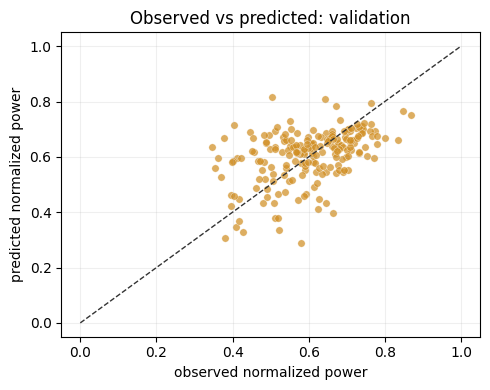

In [5]:
# Evaluate the trained run with the shared report.
baseline_report = pv.evaluate_model_report(
    baseline_run,
    bundle,
    include_test=False,
    show_advanced=show_advanced,
)
pv.print_report(baseline_report)

if baseline_report["criterion"]["passes"]:
    print("\nCriterion status: the fixed baseline meets the validation criterion.")
else:
    print("\nCriterion status: the fixed baseline does not meet the validation criterion.")

pv.plot_observed_vs_predicted(baseline_run, bundle, split="validation")
plt.show()


<br>

## 5. Fixed-Baseline-Only Test Check

`02_our_approach` already fixed the baseline configuration. For the baseline record only, we can now compare validation and test performance.

Do not use this test check to choose an intervention. The group notebooks should make intervention choices from validation evidence first, then use test only after a choice has been fixed.


In [ ]:
# Run the final held-out check after the choice is fixed.
final_baseline_report = pv.evaluate_model_report(
    baseline_run,
    bundle,
    include_test=True,
    show_advanced=show_advanced,
)
validation_row = next(row for row in final_baseline_report["metric_rows"] if row[0] == "validation")
test_row = next(row for row in final_baseline_report["metric_rows"] if row[0] == "test")

pv.print_table(
    ["Fixed-baseline-only final check", "Validation", "Test"],
    [
        ["RMSE", validation_row[2], test_row[2]],
        ["MAE", validation_row[3], test_row[3]],
        ["Key operating-range RMSE", validation_row[4], test_row[4]],
    ],
)


| Fixed-baseline-only final check | Validation | Test   |
| :------------------------------ | ---------: | -----: |
| RMSE                            |     0.1074 | 0.1071 |
| MAE                             |     0.0831 | 0.0822 |
| Key operating-range RMSE        |     0.0934 | 0.0831 |


: 

<br>

## 6. Shared Result Log

Each intervention subsection includes this table:

| Experiment | Setup | Result | Conclusion |
|---|---|---|---|
| | | | |

Record the experiment that best tests your hypothesis. In the setup column, name what changed and what stayed fixed. In the result column, use validation/report evidence, not test evidence, while choosing. In the conclusion column, state whether the evidence supported or weakened the intervention hypothesis and what you would do next.


<br>

## 7. Group Responsibilities

| Group | Notebook | Responsibility | Boundary |
|---|---|---|---|
| A | `03a_data_space_interventions.ipynb` | Investigate whether the data design supports the deployment claim | Change data sampling, split design, or collection mix |
| B | `03b_hypothesis_space_interventions.ipynb` | Investigate whether the model family can express the needed relationship | Change model-family choices such as size, regularity, activation, or allowed inputs |
| C | `03c_optimizer_space_interventions.ipynb` | Investigate whether the training objective and SGD procedure selected a good solution | Change scaling, initialization, SGD settings, or objective |

Suggested roles: one driver, one recorder, and one reporter. Work through the three subsections in your assigned notebook and keep the result log current as you go.


<br>

## 8. Report-Back Template

Prepare to report:

1. failure hypothesis;
2. evidence inspected;
3. intervention tested;
4. validation result;
5. final test check after the choice was fixed;
6. conclusion and next action.

The final score matters less than whether the process is evidence-driven and the intervention directly tests the hypothesis.


<br>

## 9. Start Breakout

Open your assigned notebook. Inspect the evidence, choose an intervention hypothesis, run the provided experiment, evaluate with the shared report, and record a conclusion before moving to the next subsection.
